In [1]:
# === Cell 1: Setup & Imports ===
# If not installed:
# !pip install torch torchvision numpy tqdm mssfp matplotlib

from __future__ import annotations
import os, json, math, random, argparse
from dataclasses import dataclass
from typing import Optional, Tuple, List, Dict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

import mssfp  # <- we rely on this; dataset['M'] must be complex [N,H,W,P]

In [2]:
# === Cell 2: Utilities (device, metrics) ===

def device_auto():
    if torch.backends.mps.is_available():
        return torch.device('mps')     # Apple Silicon
    if torch.cuda.is_available():
        return torch.device('cuda')    # NVIDIA
    return torch.device('cpu')         # CPU fallback

def psnr(x: np.ndarray, y: np.ndarray, data_range: float = 1.0) -> float:
    """Simple PSNR on numpy arrays (H, W) or (H, W, 1)."""
    x = np.asarray(x).astype(np.float32).squeeze()
    y = np.asarray(y).astype(np.float32).squeeze()
    mse = np.mean((x - y) ** 2)
    if mse <= 1e-12:
        return float('inf')
    return 20 * math.log10(data_range) - 10 * math.log10(mse)


In [3]:
# === Cell 3: Data generation from mssfp.generate_ssfp_dataset ===

def call_generate_ssfp_dataset(
    phantom_type: str = 'block',
    slices: int = 32,
    shape: int = 128,
    ids: Optional[List[int]] = None,
    npcs: int = 4,
    f: float = 500.0,
    alpha_deg: float = 60.0,
    sigma: float = 0.001,
    useRotate: bool = True,
    useDeform: bool = True
) -> Tuple[np.ndarray, Dict]:
    """
    Calls mssfp.generate_ssfp_dataset and returns:
      M: complex np.ndarray of shape [N, H, W, P]
      meta: the full dict returned by mssfp (including 'M')
    """
    if ids is None:
        ids = [1, 2, 3, 4]
    alpha = np.deg2rad(alpha_deg)
    kwargs = dict(
        phantom_type=phantom_type, slices=slices, shape=shape, ids=ids,
        npcs=npcs, f=f, alpha=alpha, sigma=sigma,
        useRotate=useRotate, useDeform=useDeform,
    )

    dataset = mssfp.generate_ssfp_dataset(**kwargs)
    if not isinstance(dataset, dict) or 'M' not in dataset:
        raise RuntimeError("mssfp.generate_ssfp_dataset must return dict with key 'M'.")
    M = dataset['M']            # [N, H, W, P] complex
    if not isinstance(M, np.ndarray) or M.ndim != 4:
        raise RuntimeError("dataset['M'] must be a 4D numpy array [N, H, W, P].")
    if not np.iscomplexobj(M):
        raise RuntimeError("dataset['M'] must be complex-valued.")
    return M, dataset


def build_inputs_and_target(M: np.ndarray, target: str = 'rss') -> Tuple[np.ndarray, np.ndarray]:
    """
    Convert complex [N, H, W, P] to model inputs/targets.

    Inputs X: real/imag pairs per PC kept in [N, H, W, 2P] (we convert to channels-first at batching time)
      - Order on last axis: [..., pc0_real, pc0_imag, pc1_real, pc1_imag, ...]

    Target Y: band-free scalar image via:
      - 'rss'  : sqrt(sum_p |M|^2)  -> [N, H, W, 1]
      - 'csum' : |sum_p M|         -> [N, H, W, 1]

    Per-sample normalization:
      - scale = 99th percentile of |M| for that sample. Divide both X and Y by the same scale.
    """
    if not np.iscomplexobj(M):
        raise RuntimeError("Expected complex dataset['M']; got non-complex array.")

    real = M.real  # [N, H, W, P]
    imag = M.imag  # [N, H, W, P]
    X = np.concatenate([real, imag], axis=-1)  # [N, H, W, 2P]

    if target.lower() == 'csum':
        Yc = np.abs(np.sum(M, axis=-1))        # [N, H, W]
    else:
        Yc = np.sqrt(np.sum(np.abs(M) ** 2, axis=-1))  # [N, H, W]
    Y = Yc.astype(np.float32)[..., None]       # [N, H, W, 1]

    # Per-sample normalization with |M|
    mags = np.abs(M)
    for i in range(M.shape[0]):
        s = float(np.percentile(mags[i], 99))
        if s > 1e-6:
            X[i] /= s
            Y[i] /= s

    # Clip for stability
    X = np.clip(X, -3.0, 3.0).astype(np.float32)   # real/imag can be negative
    Y = np.clip(Y,  0.0, 3.0).astype(np.float32)
    return X, Y


class PCSSFPDataset(Dataset):
    """
    Preserves [N, H, W, 2P] in memory and converts to tensors with channels-first at __getitem__.
    """
    def __init__(self, gen_kwargs: dict, target: str = 'rss'):
        M, meta = call_generate_ssfp_dataset(**gen_kwargs)
        X, Y = build_inputs_and_target(M, target=target)
        self.X = X   # [N, H, W, 2P], float32
        self.Y = Y   # [N, H, W, 1],  float32
        self.info = {
            'N': int(self.X.shape[0]),
            'P': int(self.X.shape[-1] // 2),
            'H': int(self.X.shape[1]),
            'W': int(self.X.shape[2]),
            'target': target,
            'phantom': str(gen_kwargs.get('phantom_type', 'block')),
        }

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        # [H, W, 2P] -> [2P, H, W], [H, W, 1] -> [1, H, W]
        X = torch.from_numpy(np.moveaxis(self.X[idx], -1, 0))
        Y = torch.from_numpy(np.moveaxis(self.Y[idx], -1, 0))
        return X, Y


In [4]:
# === Cell 4: Model (U-Net + DDPM) — FIXED to use x_t + cond ===

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.GroupNorm(8, out_ch), nn.SiLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.GroupNorm(8, out_ch), nn.SiLU(),
        )
    def forward(self, x):
        return self.net(x)

class UNet(nn.Module):
    def __init__(self, in_ch, base=48):
        super().__init__()
        # in_ch will be: 1 (x_t) + 2P (cond Re/Im) + 1 (time map added inside forward) -> so we build with in_ch+1
        self.d1 = DoubleConv(in_ch + 1, base)   # +1 time embedding plane
        self.p1 = nn.Conv2d(base, base, 2, stride=2)
        self.d2 = DoubleConv(base, base * 2)
        self.p2 = nn.Conv2d(base * 2, base * 2, 2, stride=2)
        self.d3 = DoubleConv(base * 2, base * 4)
        self.u2 = nn.ConvTranspose2d(base * 4, base * 2, 2, stride=2)
        self.u1 = nn.ConvTranspose2d(base * 2, base, 2, stride=2)
        self.c2 = DoubleConv(base * 4, base * 2)
        self.c1 = DoubleConv(base * 2, base)
        self.out = nn.Conv2d(base, 1, 1)

    def forward(self, x_in, t_emb):
        """
        x_in = concat([x_t (B,1,H,W), cond (B,2P,H,W)], dim=1)
        """
        B, C, H, W = x_in.shape
        tmap = t_emb.view(B, 1, 1, 1).expand(B, 1, H, W)
        x = torch.cat([x_in, tmap], dim=1)
        x1 = self.d1(x)
        x2 = self.d2(self.p1(x1))
        x3 = self.d3(self.p2(x2))
        y2 = self.c2(torch.cat([self.u2(x3), x2], dim=1))
        y1 = self.c1(torch.cat([self.u1(y2), x1], dim=1))
        return self.out(y1)

class DDPM(nn.Module):
    def __init__(self, model: UNet, timesteps=400, beta_start=1e-4, beta_end=0.02):
        super().__init__()
        self.model = model
        self.T = timesteps
        betas = torch.linspace(beta_start, beta_end, timesteps)
        alphas = 1.0 - betas
        self.register_buffer('betas', betas)
        self.register_buffer('alphas', alphas)
        self.register_buffer('alphas_bar', torch.cumprod(alphas, dim=0))

    def add_noise(self, x0, t, noise):
        a_bar = self.alphas_bar[t].view(-1, 1, 1, 1)
        return torch.sqrt(a_bar) * x0 + torch.sqrt(1 - a_bar) * noise

    def p_losses(self, cond, x0, t):
        """
        cond: (B, 2P, H, W)
        x0  : (B, 1,  H, W)
        """
        noise = torch.randn_like(x0)
        x_t = self.add_noise(x0, t, noise)
        t_norm = (t.float() / (self.T - 1)).clamp(0, 1)
        # IMPORTANT: pass x_t together with cond into the model
        pred = self.model(torch.cat([x_t, cond], dim=1), t_norm)
        return F.smooth_l1_loss(pred, noise)

    @torch.no_grad()
    def sample(self, cond, device):
        """
        cond: (B, 2P, H, W)
        returns: denoised (B,1,H,W)
        """
        B, _, H, W = cond.shape
        x = torch.randn(B, 1, H, W, device=device)
        for ti in reversed(range(self.T)):
            t = torch.full((B,), ti, device=device, dtype=torch.long)
            t_norm = (t.float() / (self.T - 1)).clamp(0, 1)
            # IMPORTANT: condition on current x_t and cond
            eps = self.model(torch.cat([x, cond], dim=1), t_norm)
            beta = self.betas[ti]
            alpha = self.alphas[ti]
            alpha_bar = self.alphas_bar[ti]
            coef1 = 1 / torch.sqrt(alpha)
            coef2 = (1 - alpha) / torch.sqrt(1 - alpha_bar)
            x = coef1 * (x - coef2 * eps)
            if ti > 0:
                x = x + torch.sqrt(beta) * torch.randn_like(x)
        return x.clamp(0, 3.0)


In [5]:
# === Cell 5: Configs, DataLoaders, Train/Infer helpers (fixed) ===
from dataclasses import dataclass, field
from typing import Optional, Tuple, Dict
import os, json
import numpy as np
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm

# Assumes the following are already defined in earlier cells:
# - device_auto()
# - PCSSFPDataset
# - UNet, DDPM  (Cell 4 fixed version that uses x_t + cond)
# - call_generate_ssfp_dataset, build_inputs_and_target
# - psnr

@dataclass
class GenCfg:
    phantom_type: str = 'block'
    slices: int = 32
    shape: int = 128
    ids: Tuple[int, ...] = (1, 2, 3, 4)
    npcs: int = 4
    f: float = 500.0
    alpha_deg: float = 60.0
    sigma: float = 0.001
    useRotate: bool = True
    useDeform: bool = True
    # NOTE: no seed argument (mssfp.generate_ssfp_dataset doesn't accept it)

@dataclass
class RunCfg:
    # data generation
    gen: GenCfg = field(default_factory=GenCfg)  # <-- fixed: use default_factory
    # training
    target: str = 'rss'  # 'rss' or 'csum'
    batch: int = 8
    epochs: int = 5
    base: int = 48
    lr: float = 2e-4
    timesteps: int = 400
    save_dir: str = 'runs'

def make_loaders(cfg: RunCfg):
    # Train set
    gen_train = cfg.gen.__dict__.copy()
    gen_train['ids'] = list(gen_train['ids'])
    ds_tr = PCSSFPDataset(gen_train, target=cfg.target)

    # Val set: fewer slices for quick snapshots
    gen_val = cfg.gen.__dict__.copy()
    gen_val['ids'] = list(gen_val['ids'])
    gen_val['slices'] = max(4, gen_val['slices'] // 8)
    ds_va = PCSSFPDataset(gen_val, target=cfg.target)

    dl_tr = DataLoader(ds_tr, batch_size=cfg.batch, shuffle=True, num_workers=0)
    dl_va = DataLoader(ds_va, batch_size=cfg.batch, shuffle=False, num_workers=0)
    return ds_tr, ds_va, dl_tr, dl_va

def train_loop(cfg: RunCfg):
    os.makedirs(cfg.save_dir, exist_ok=True)
    device = device_auto()

    ds_tr, ds_va, dl_tr, dl_va = make_loaders(cfg)
    cond_ch = ds_tr.X.shape[-1]          # 2 * P (real/imag pairs)
    in_ch   = 1 + cond_ch                # +1 channel for x_t
    model   = UNet(in_ch=in_ch, base=cfg.base)
    ddpm    = DDPM(model, timesteps=cfg.timesteps).to(device)
    opt     = torch.optim.AdamW(ddpm.parameters(), lr=cfg.lr, weight_decay=1e-4)

    # Save dataset summary for reproducibility
    summary = {'train_info': ds_tr.info, 'val_info': ds_va.info}
    with open(os.path.join(cfg.save_dir, 'dataset_info.json'), 'w') as f:
        json.dump(summary, f, indent=2)
    print("Dataset summary:\n", json.dumps(summary, indent=2))

    for epoch in range(cfg.epochs):
        ddpm.train()
        pbar = tqdm(dl_tr, desc=f"epoch {epoch+1}/{cfg.epochs}")
        for X, Y in pbar:
            # X: [B, 2P, H, W]   (cond),  Y: [B, 1, H, W] (target)
            X, Y = X.to(device), Y.to(device)
            t = torch.randint(0, ddpm.T, (X.size(0),), device=device)
            loss = ddpm.p_losses(cond=X, x0=Y, t=t)  # <-- DDPM sees x_t + cond inside
            opt.zero_grad(set_to_none=True)
            loss.backward()
            # Optional stabilizer:
            # torch.nn.utils.clip_grad_norm_(ddpm.parameters(), 1.0)
            opt.step()
            pbar.set_postfix({'loss': float(loss.detach().cpu())})

        # Validation snapshot & checkpoint
        ddpm.eval()
        with torch.no_grad():
            Xv, Yv = next(iter(dl_va))
            Xv, Yv = Xv.to(device), Yv.to(device)
            Yhat = ddpm.sample(cond=Xv[:4], device=device)
            grid = torch.cat([Yv[:4], Yhat], dim=0).cpu().numpy()
            np.save(os.path.join(cfg.save_dir, f'preview_epoch_{epoch+1}.npy'), grid)

        torch.save(
            {'model': ddpm.state_dict(),
             'cfg': {
                 'gen': cfg.gen.__dict__,
                 'target': cfg.target,
                 'batch': cfg.batch,
                 'epochs': cfg.epochs,
                 'base': cfg.base,
                 'lr': cfg.lr,
                 'timesteps': cfg.timesteps,
                 'save_dir': cfg.save_dir,
             }},
            os.path.join(cfg.save_dir, 'last.pt')
        )
    print('Training complete. Check', cfg.save_dir)

@torch.no_grad()
def infer_sample(ckpt_path='runs/last.pt',
                 gen_overrides: Optional[dict] = None,
                 target: str = 'rss',
                 save_dir: str = 'runs'):
    device = device_auto()
    ckpt = torch.load(ckpt_path, map_location=device)
    cfgd = ckpt.get('cfg', {})
    gen_cfg = cfgd.get('gen', {})
    if gen_overrides:
        gen_cfg.update(gen_overrides)

    # Build a small synthetic batch from mssfp
    M, _ = call_generate_ssfp_dataset(**gen_cfg)
    X_np, Y_np = build_inputs_and_target(M, target=target)
    # Convert to tensors, channel-first
    X = torch.from_numpy(np.moveaxis(X_np, -1, 1)[:4]).to(device)  # [B, 2P, H, W]
    Y = torch.from_numpy(np.moveaxis(Y_np, -1, 1)[:4]).to(device)  # [B, 1, H, W]

    cond_ch = X.shape[1]
    in_ch   = 1 + cond_ch
    base    = int(cfgd.get('base', 48))
    timesteps = int(cfgd.get('timesteps', 400))
    model   = UNet(in_ch=in_ch, base=base)
    ddpm    = DDPM(model, timesteps=timesteps).to(device)
    ddpm.load_state_dict(ckpt['model'])
    ddpm.eval()

    Yhat = ddpm.sample(cond=X, device=device)

    # Save and report a simple PSNR on the first example
    os.makedirs(save_dir, exist_ok=True)
    out = torch.cat([Y, Yhat], dim=0).cpu().numpy()
    np.save(os.path.join(save_dir, 'infer_sample.npy'), out)

    y0 = Y[0, 0].detach().cpu().numpy()
    yhat0 = Yhat[0, 0].detach().cpu().numpy()
    print("PSNR (sample[0]):", psnr(y0, yhat0, data_range=3.0))
    print('Saved:', os.path.join(save_dir, 'infer_sample.npy'))


In [6]:
# === Cell 6: One-call runner + defaults ===

def run_experiment(
    phantom: str = 'block',
    slices: int = 32,
    shape: int = 128,
    ids: Tuple[int, ...] = (1, 2, 3, 4),
    npcs: int = 4,
    f: float = 500.0,
    alpha_deg: float = 60.0,
    sigma: float = 0.001,
    rotate: bool = True,
    deform: bool = True,
    seed: Optional[int] = None,
    target: str = 'rss',
    batch: int = 8,
    epochs: int = 5,
    base: int = 48,
    lr: float = 2e-4,
    timesteps: int = 400,
    save_dir: str = 'runs',
):
    gen = GenCfg(
        phantom_type=phantom, slices=slices, shape=shape, ids=ids,
        npcs=npcs, f=f, alpha_deg=alpha_deg, sigma=sigma,
        useRotate=rotate, useDeform=deform
    )
    cfg = RunCfg(gen=gen, target=target, batch=batch, epochs=epochs,
                 base=base, lr=lr, timesteps=timesteps, save_dir=save_dir)
    train_loop(cfg)
    infer_sample(
        os.path.join(save_dir, 'last.pt'),
        gen_overrides={'slices': max(4, slices // 8)},
        target=target,
        save_dir=save_dir
    )


In [9]:
# === Cell 7: Train (example) ===
# Adjust parameters as needed. RSS is generally a safe target.

run_experiment(
    phantom='block',
    slices=128,
    shape=128,
    ids=(1, 2, 3, 4),
    npcs=4,
    f=500.0,
    alpha_deg=60.0,
    sigma=0.001,
    rotate=True,
    deform=True,
    target='rss',     # or 'csum'
    batch=8,
    epochs=100,
    base=48,
    lr=1e-4,
    timesteps=400,
    save_dir='runs'
)


Generating phantom...
Generating SSFP dataset...
Dataset complete.
Dataset shape: (128, 128, 128, 4)
Generating phantom...
Generating SSFP dataset...
Dataset complete.
Dataset shape: (16, 128, 128, 4)
Dataset summary:
 {
  "train_info": {
    "N": 128,
    "P": 4,
    "H": 128,
    "W": 128,
    "target": "rss",
    "phantom": "block"
  },
  "val_info": {
    "N": 16,
    "P": 4,
    "H": 128,
    "W": 128,
    "target": "rss",
    "phantom": "block"
  }
}


epoch 100/100: 100%|██████████| 16/16 [00:02<00:00,  5.46it/s, loss=0.00162]


Training complete. Check runs
Generating phantom...
Generating SSFP dataset...
Dataset complete.
Dataset shape: (16, 128, 128, 4)
PSNR (sample[0]): 19.403803547051876
Saved: runs/infer_sample.npy


Generating phantom...
Generating SSFP dataset...
Dataset complete.
Dataset shape: (4, 128, 128, 4)


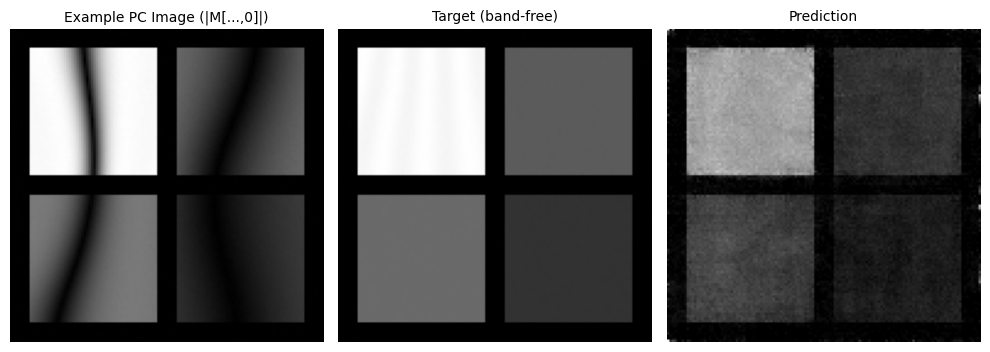

In [8]:
# === Cell 8: Visualize example PC input, target, and prediction ===
import matplotlib.pyplot as plt
import numpy as np
import os, math

def show_panel(images, titles=None, cols=3, figsize=(12, 4), vmin=None, vmax=None, cmap='gray'):
    n = len(images)
    rows = math.ceil(n / cols)
    plt.figure(figsize=figsize)
    for i, im in enumerate(images, 1):
        ax = plt.subplot(rows, cols, i)
        ax.imshow(im, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.axis('off')
        if titles and i-1 < len(titles):
            ax.set_title(titles[i-1], fontsize=10)
    plt.tight_layout()
    plt.show()

stack_path = 'runs/infer_sample.npy'

if os.path.exists(stack_path):
    arr = np.load(stack_path)  # shape: [2*B, 1, H, W]
    B = arr.shape[0] // 2
    GT  = arr[:B, 0]   # ground truth (band-free)
    PRD = arr[B:, 0]   # model prediction

    # --- Regenerate a small dataset to get a PC image ---
    from mssfp import generate_ssfp_dataset
    dataset = generate_ssfp_dataset(phantom_type='block', slices=4, shape=128, ids=[1,2,3,4],
                                    npcs=4, f=500, alpha=np.deg2rad(60),
                                    sigma=0.001, useRotate=True, useDeform=True)
    M = dataset['M']  # [N,H,W,P], complex
    pc0_mag = np.abs(M[0, :, :, 0])  # magnitude of the first phase cycle

    # --- Display ---
    show_panel(
        [pc0_mag, GT[0], PRD[0]],
        titles=['Example PC Image (|M[...,0]|)', 'Target (band-free)', 'Prediction'],
        cols=3,
        figsize=(10, 4),
        cmap='gray'
    )
else:
    print("Run the training/inference cells first to generate 'runs/infer_sample.npy'.")
